In [8]:
import sys, os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import h5py
# 加入 Jucker 函數庫
sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/Jucker_Climate/aostools/")
import climate

In [6]:
def set_size(w,h, ax=None):
	""" w, h: width, height in inches """
	if not ax: ax=plt.gca()
	l = ax.figure.subplotpars.left
	r = ax.figure.subplotpars.right
	t = ax.figure.subplotpars.top
	b = ax.figure.subplotpars.bottom
	figw = float(w)/(r-l)
	figh = float(h)/(t-b)
	ax.figure.set_size_inches(figw, figh)

In [11]:
PR = 0  # Change as needed
last_n = 5000  # number of last time steps to read

# File paths
u_file = f"/data92/PeterChang/Dycore_data/PR{PR}/u/PR{PR}_500_20000day_u_6hourly.h5"
v_file = f"/data92/PeterChang/Dycore_data/PR{PR}/v/PR{PR}_500_20000day_v_6hourly.h5"
t_file = f"/data92/PeterChang/Dycore_data/PR{PR}/t/PR{PR}_500_20000day_t_6hourly.h5"
t_file = f"/data92/PeterChang/Dycore_data/PR{PR}/t/PR{PR}_500_20000day_t_6hourly.h5"
w_file = f"/data92/PeterChang/Dycore_data/PR{PR}/w/PR{PR}_500_20000day_w_6hourly.h5"
p_file = f"/data92/PeterChang/Dycore_data/PR{PR}/p/PR{PR}_500_20000day_p_6hourly.h5"
ps_file = f"/data92/PeterChang/Dycore_data/PR{PR}/ps/PR{PR}_500_20000day_ps_6hourly.h5"


# Read only the last `last_n` time steps of the main dataset in each file
def read_last_timesteps(file_path, last_n):
    with h5py.File(file_path, 'r') as f:
        # Assume there's only one dataset or we know the key
        data_key = list(f.keys())[0]  # e.g., 'u'
        dset = f[data_key]
        total_time = dset.shape[0]
        return dset[-last_n:, ...]  # last 5000 time steps

# Load data slices
u_last = read_last_timesteps(u_file, last_n)
v_last = read_last_timesteps(v_file, last_n)
t_last = read_last_timesteps(t_file, last_n)
w_last = read_last_timesteps(w_file, last_n)
p_last = read_last_timesteps(p_file, last_n)  # shape likely (time, y, x)
ps_last = read_last_timesteps(ps_file, last_n)  # shape likely (time, y, x)


# Confirm shapes (optional)
print("u:", u_last.shape)
print("v:", v_last.shape)
print("t:", t_last.shape)
print("w:", w_last.shape)
print("p:", p_last.shape)
print("ps:", ps_last.shape)



u: (5000, 20, 64, 128)
v: (5000, 20, 64, 128)
t: (5000, 20, 64, 128)
w: (5000, 20, 64, 128)
p: (5000, 20, 64, 128)
ps: (5000, 1, 64, 128)


In [12]:
p1d = p_last.mean(axis=(0,2,3))

In [13]:
y = np.linspace(-90, 90, 64)
yy, pp = np.meshgrid(y, p1d)

In [240]:
import sys
import importlib

sys.path.append("/data92/PeterChang/back_to_master1220/Moist_Dycore/Jucker_Climate/aostools/")
import climate
importlib.reload(climate)  # ← 強制重新載入

<module 'climate' from '/data92/PeterChang/back_to_master1220/Moist_Dycore/Jucker_Climate/aostools/climate.py'>

In [241]:
ep1, ep2, div1, dthdp, vptp = climate.ComputeEPfluxDiv(y, p1d / 100, u_last, v_last, t_last)


In [242]:
ep1.shape

(5000, 20, 64)

In [35]:
f = np.load("/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/result/ep_flux_PR50_positive.npz")
print(f.keys())
ep1 = f["ep1"][:]
ep2 = f["ep2"][:]


KeysView(NpzFile '/data92/PeterChang/back_to_master1220/Moist_Dycore/EPflux/result/ep_flux_PR50_positive.npz' with keys: ep1, ep2, y, p1d)


(array([[ 2.41835729e+12, -1.06678454e+13, -2.36916222e+13,
         -3.74454918e+13, -5.44492092e+13, -7.79515077e+13,
         -1.10417498e+14, -1.55383069e+14, -2.15730684e+14,
         -2.89407809e+14, -3.69722523e+14, -4.46888269e+14,
         -5.11671637e+14, -5.58300499e+14, -5.82412223e+14,
         -5.82088215e+14, -5.59600378e+14, -5.17256975e+14,
         -4.57366089e+14, -3.84388564e+14, -3.03439102e+14,
         -2.21941129e+14, -1.49371058e+14, -9.20638893e+13,
         -5.17594441e+13, -2.65970080e+13, -1.23857129e+13,
         -5.05061439e+12, -1.67949242e+12, -3.88602740e+11,
         -3.92887554e+10, -1.14223241e-20],
        [ 1.10225964e+13,  4.14917512e+11, -2.07224767e+13,
         -5.71102367e+13, -1.15367834e+14, -2.01356515e+14,
         -3.05216715e+14, -4.14160682e+14, -5.27619733e+14,
         -6.36789170e+14, -7.15717497e+14, -7.47908824e+14,
         -7.37082809e+14, -6.94480679e+14, -6.26825434e+14,
         -5.27524227e+14, -3.85813976e+14, -2.19767505e+

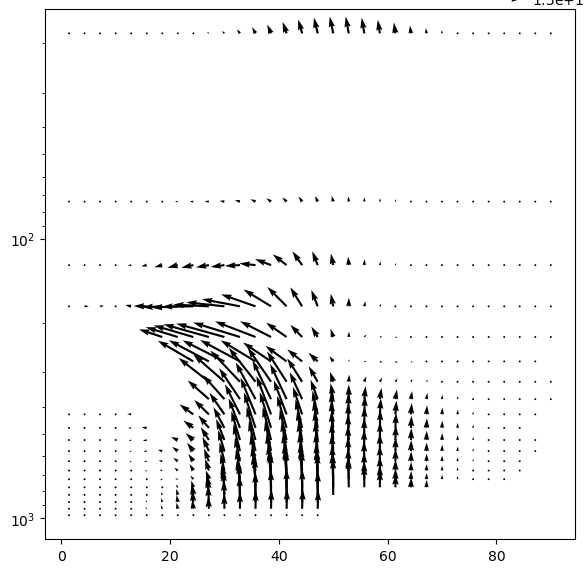

In [36]:
fig, ax = plt.subplots(1)
set_size(5.3,5.3,ax)
climate.PlotEPfluxArrows(y[32:], p1d / 100, ep1[:,:,32:].mean(axis=0), ep2[:,:,32:].mean(axis=0), fig, ax, yscale="log")
